# 03 - Comparativa global: centroide vs KNN-DtC vs CAE-CNNLoc 2D-Temporal

Une los tres métodos en un único marco comparativo y produce los artefactos que se insertarán en el capítulo 4 de la memoria PEC4:

- Tabla unificada con error medio, mediano y p95 para cada método.
- CDFs comparativas en los tres escenarios relevantes (auto, cross-pose, cross-device + cross-pose).
- Tabla LaTeX lista para copiar al `.tex`.

## Convenciones

* `auto` — entrenamiento y evaluación sobre el mismo subset.
* `cross-pose` — entrenamiento y evaluación en el mismo dispositivo, distinta postura.
* `cross-device` — distinto dispositivo, misma postura.
* `cross-both` — distinto dispositivo y distinta postura.

El centroide ponderado no tiene fase de entrenamiento, por lo que solo aparece en la categoría `auto`. Los otros dos métodos cubren los cuatro escenarios.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

df_centroid = pd.read_csv(RESULTS / '01_baselines_centroid.csv')
df_knn = pd.read_csv(RESULTS / '01_baselines_knn_dtc_per_pair.csv')
df_cnn = pd.read_csv(RESULTS / '02_cnnloc_full_results.csv')
print('centroide:', df_centroid.shape, '| KNN-DtC:', df_knn.shape, '| CAE-CNNLoc:', df_cnn.shape)
print('CNN train_sets:', sorted(df_cnn['train_set'].unique()))
print('CNN test_sets :', sorted(df_cnn['test_set'].unique()))

centroide: (18099, 11) | KNN-DtC: (235287, 6) | CAE-CNNLoc: (271060, 14)
CNN train_sets: ['POCO#STANDING', 'POCO#TRIPOD', 'SAMSUNG#STANDING', 'SAMSUNG#TRIPOD']
CNN test_sets : ['POCO#STANDING', 'POCO#TRIPOD', 'SAMSUNG#STANDING', 'SAMSUNG#TRIPOD']


## Etiquetar el escenario por fila

Definimos `scenario` a partir de la combinación (train_set, test_set), que para el centroide siempre es `auto`. Para KNN-DtC el `train_set` es la cadena `DEVICE#TYPE` y el set de evaluación se infiere del par (device, measuring_type) almacenado en cada fila.

In [2]:
def scenario_from_pair(train_key, test_key):
    if train_key == test_key:
        return 'auto'
    t_dev, t_pose = train_key.split('#')
    e_dev, e_pose = test_key.split('#')
    if t_dev == e_dev:
        return 'cross-pose'
    if t_pose == e_pose:
        return 'cross-device'
    return 'cross-both'

# centroide: every row is auto
df_centroid['test_set'] = df_centroid['device'].astype(str) + '#' + df_centroid['measuring_type'].astype(str)
df_centroid['train_set'] = df_centroid['test_set']
df_centroid['scenario'] = 'auto'
df_centroid['family'] = 'centroide'
df_centroid['variant'] = 'centroide_w' + df_centroid['window'].astype(str)

# KNN-DtC: per-pair CSV already has explicit train_set and test_set
df_knn['scenario'] = [scenario_from_pair(t, e) for t, e in zip(df_knn['train_set'], df_knn['test_set'])]
df_knn['family'] = 'KNN-DtC'
df_knn['variant'] = df_knn['method'] + '_w' + df_knn['window'].astype(str)

# CAE-CNNLoc: scenario from train_set & test_set
df_cnn['scenario'] = [scenario_from_pair(t, e) for t, e in zip(df_cnn['train_set'], df_cnn['test_set'])]
df_cnn['family'] = 'CAE-CNNLoc-2D'
df_cnn['variant'] = df_cnn['method']  # already encodes N

for name, df in [('centroide', df_centroid), ('KNN-DtC', df_knn), ('CAE-CNNLoc', df_cnn)]:
    print(name, dict(df['scenario'].value_counts()))

centroide {'auto': np.int64(18099)}
KNN-DtC {'cross-pose': np.int64(72396), 'cross-device': np.int64(72396), 'cross-both': np.int64(72396), 'auto': np.int64(18099)}
CAE-CNNLoc {'auto': np.int64(67765), 'cross-pose': np.int64(67765), 'cross-device': np.int64(67765), 'cross-both': np.int64(67765)}


## Esquema unificado

Recortamos a las columnas comunes para concatenar los tres dataframes en uno solo.

In [3]:
common_cols = ['family', 'variant', 'train_set', 'test_set', 'scenario', 'error']
df_all = pd.concat(
    [df_centroid[common_cols], df_knn[common_cols], df_cnn[common_cols]],
    ignore_index=True,
)
df_all.to_csv(RESULTS / '03_unified_results.csv', index=False)
print('Unified rows:', len(df_all))
print(df_all['family'].value_counts())

Unified rows: 524446
family
CAE-CNNLoc-2D    271060
KNN-DtC          235287
centroide         18099
Name: count, dtype: int64


## Selección de la mejor variante por familia y escenario

Para que la comparativa sea ecuánime, en cada escenario tomamos:

- la mejor variante de centroide (cuál ventana temporal),
- la mejor variante de KNN-DtC (combinación de $k$ y ventana),
- el resultado único de CAE-CNNLoc 2D-Temporal (N=16, 5 semillas).

El criterio de "mejor" es **menor error medio**.

In [4]:
summary_variant = (
    df_all.groupby(['family', 'variant', 'scenario'])['error']
          .agg(mean='mean', median='median', std='std',
               p75=lambda s: float(np.percentile(s, 75)),
               p95=lambda s: float(np.percentile(s, 95)),
               n='count')
          .reset_index()
)
best_per_family_scenario = (
    summary_variant.sort_values(['family', 'scenario', 'mean'])
                  .groupby(['family', 'scenario'])
                  .head(1)
                  .reset_index(drop=True)
)
best_per_family_scenario.to_csv(RESULTS / '03_best_per_family_scenario.csv', index=False)
print(best_per_family_scenario.round(3).to_string(index=False))

       family           variant     scenario  mean  median   std   p75   p95     n
CAE-CNNLoc-2D CAE-CNNLoc-2D-N16         auto 0.238   0.202 0.160 0.313 0.550 67765
CAE-CNNLoc-2D CAE-CNNLoc-2D-N16   cross-both 2.054   1.715 1.455 2.744 4.952 67765
CAE-CNNLoc-2D CAE-CNNLoc-2D-N16 cross-device 1.999   1.642 1.463 2.657 5.023 67765
CAE-CNNLoc-2D CAE-CNNLoc-2D-N16   cross-pose 0.832   0.724 0.594 1.084 1.925 67765
      KNN-DtC    KNN-DtC-k1_w1s         auto 0.000   0.000 0.000 0.000 0.000  2725
      KNN-DtC    KNN-DtC-k1_w5s   cross-both 0.559   0.000 0.912 1.389 2.545   621
      KNN-DtC    KNN-DtC-k1_w5s cross-device 0.273   0.000 0.689 0.000 1.626   621
      KNN-DtC    KNN-DtC-k1_w5s   cross-pose 0.474   0.000 0.829 1.389 1.635   621
    centroide     centroide_w5s         auto 1.721   1.488 0.777 2.287 2.980   621


## Tabla compacta para la memoria

Reorganizamos en formato pivot: filas = método (mejor variante), columnas = escenario, celdas = error medio (m).

In [5]:
scenarios_order = ['auto', 'cross-pose', 'cross-device', 'cross-both']
pivot_mean = best_per_family_scenario.pivot(index='family', columns='scenario', values='mean')
pivot_median = best_per_family_scenario.pivot(index='family', columns='scenario', values='median')
pivot_p95 = best_per_family_scenario.pivot(index='family', columns='scenario', values='p95')

for name, p in [('mean (m)', pivot_mean), ('median (m)', pivot_median), ('p95 (m)', pivot_p95)]:
    p = p.reindex(columns=[c for c in scenarios_order if c in p.columns])
    p = p.reindex(['centroide', 'KNN-DtC', 'CAE-CNNLoc-2D'])
    print(f'\n=== {name} ===')
    print(p.round(3).to_string())


=== mean (m) ===
scenario       auto  cross-pose  cross-device  cross-both
family                                                   
centroide     1.721         NaN           NaN         NaN
KNN-DtC       0.000       0.474         0.273       0.559
CAE-CNNLoc-2D 0.238       0.832         1.999       2.054

=== median (m) ===
scenario       auto  cross-pose  cross-device  cross-both
family                                                   
centroide     1.488         NaN           NaN         NaN
KNN-DtC       0.000       0.000         0.000       0.000
CAE-CNNLoc-2D 0.202       0.724         1.642       1.715

=== p95 (m) ===
scenario       auto  cross-pose  cross-device  cross-both
family                                                   
centroide     2.980         NaN           NaN         NaN
KNN-DtC       0.000       1.635         1.626       2.545
CAE-CNNLoc-2D 0.550       1.925         5.023       4.952


## CDFs comparativas

Tres paneles, uno por escenario relevante de generalización (`cross-pose`, `cross-device`, `cross-both`). El centroide solo aparece en `auto`, así que generamos dos figuras: una para `auto` y otra para los tres de generalización.

In [6]:
def plot_cdf(ax, errors, label, **kw):
    e = np.sort(np.asarray(errors))
    cdf = np.arange(1, len(e) + 1) / len(e)
    ax.plot(e, cdf, label=label, **kw)

def best_variant_for(family, scenario):
    row = best_per_family_scenario.query('family == @family & scenario == @scenario')
    if row.empty:
        return None
    return row.iloc[0]['variant']

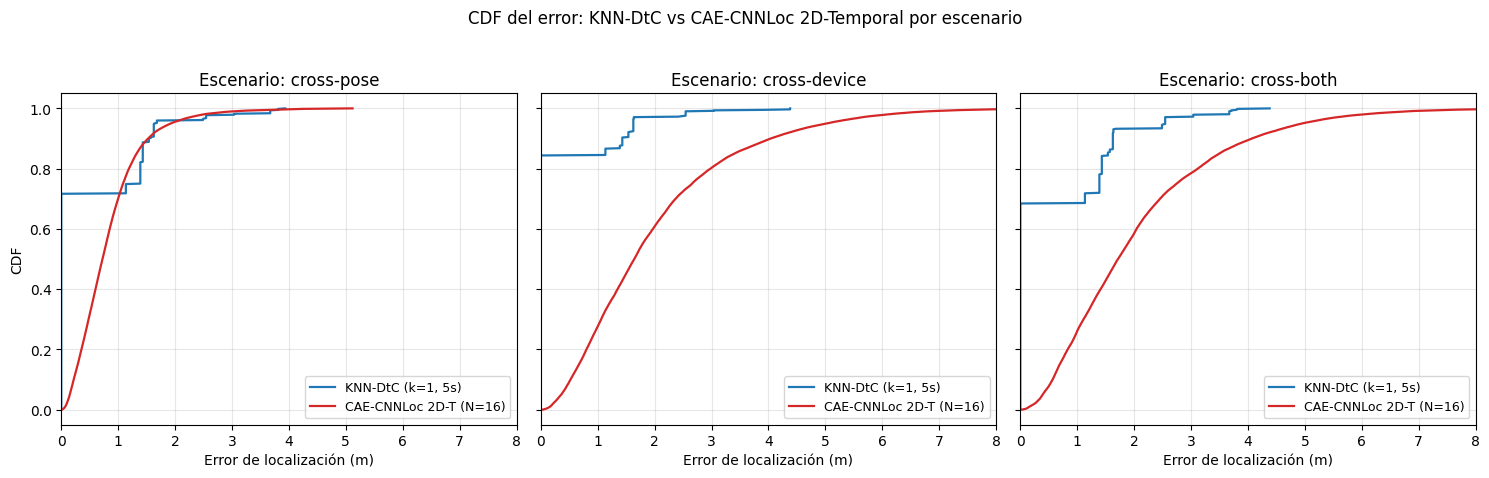

In [7]:
FIXED_VARIANTS = {
    'KNN-DtC': 'KNN-DtC-k1_w5s',
    'CAE-CNNLoc-2D': 'CAE-CNNLoc-2D-N16',
}
LABEL_MAP = {
    'KNN-DtC': 'KNN-DtC (k=1, 5s)',
    'CAE-CNNLoc-2D': 'CAE-CNNLoc 2D-T (N=16)',
}
fig, axes = plt.subplots(3, 1, figsize=(7.0, 9.6), sharex=True)
for ax, scen in zip(axes, ['cross-pose', 'cross-device', 'cross-both']):
    for fam, color in [('KNN-DtC', 'tab:blue'), ('CAE-CNNLoc-2D', 'tab:red')]:
        var = FIXED_VARIANTS[fam]
        sub = df_all[(df_all['family'] == fam) & (df_all['variant'] == var) &
                     (df_all['scenario'] == scen)]
        if sub.empty:
            continue
        plot_cdf(ax, sub['error'], label=LABEL_MAP[fam], color=color, linewidth=1.8)
    ax.set_xlim(0, 8)
    ax.set_ylabel('CDF')
    ax.set_title(f'Escenario: {scen}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10, loc='lower right')
axes[-1].set_xlabel('Error de localización (m)')
fig.suptitle('CDF del error: KNN-DtC vs CAE-CNNLoc 2D-Temporal por escenario', y=0.995)
fig.tight_layout()
fig.savefig(RESULTS / '03_comparativa_cdf_generalisation.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / '03_comparativa_cdf_generalisation.pdf', bbox_inches='tight')
plt.show()

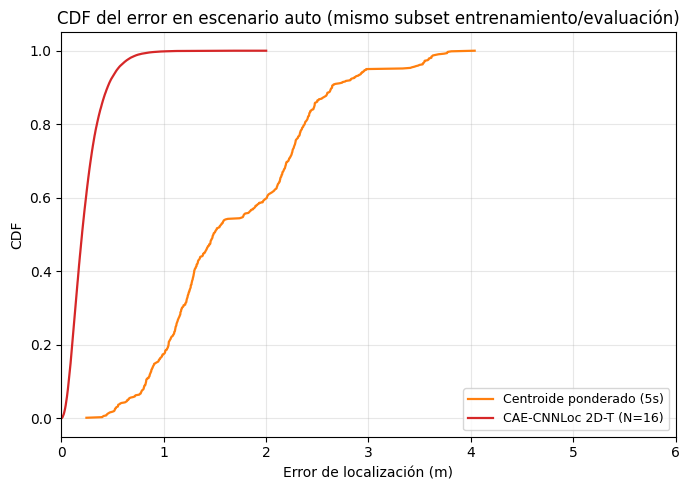

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
auto_specs = [
    ('centroide', best_variant_for('centroide', 'auto'), 'tab:orange', 'Centroide ponderado (5s)'),
    ('CAE-CNNLoc-2D', 'CAE-CNNLoc-2D-N16', 'tab:red', 'CAE-CNNLoc 2D-T (N=16)'),
]
for fam, var, color, label in auto_specs:
    if var is None:
        continue
    sub = df_all[(df_all['family'] == fam) & (df_all['variant'] == var) & (df_all['scenario'] == 'auto')]
    plot_cdf(ax, sub['error'], label=label, color=color, linewidth=1.6)
ax.set_xlim(0, 6)
ax.set_xlabel('Error de localización (m)')
ax.set_ylabel('CDF')
ax.set_title('CDF del error en escenario auto (mismo subset entrenamiento/evaluación)')
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(RESULTS / '03_comparativa_cdf_auto.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / '03_comparativa_cdf_auto.pdf', bbox_inches='tight')
plt.show()

## Tabla LaTeX para insertar en `main_PEC4.tex`

Generamos un fragmento `tabular` con tres filas (un método cada una) y cuatro columnas (un escenario cada una), guardado como `results/03_table_compact.tex`.

In [9]:
row_order = ['centroide', 'KNN-DtC', 'CAE-CNNLoc-2D']
label_map = {
    'centroide': 'Centroide ponderado',
    'KNN-DtC': 'KNN-DtC ($k{=}1$, ventana 5\\,s)',
    'CAE-CNNLoc-2D': 'CAE-CNNLoc 2D-Temporal ($N{=}16$)',
}
# Lock KNN-DtC to its best window (5s) and k=1 for consistency across scenarios
fixed_knn_variant = 'KNN-DtC-k1_w5s'
fixed_cnn_variant = 'CAE-CNNLoc-2D-N16'
rows = []
for fam in row_order:
    cells = [label_map[fam]]
    for scen in scenarios_order:
        if fam == 'KNN-DtC':
            sel = summary_variant.query('family == @fam & scenario == @scen & variant == @fixed_knn_variant')
            if scen == 'auto':
                cells.append('$0$ (trivial)\\textsuperscript{*}')
                continue
        elif fam == 'CAE-CNNLoc-2D':
            sel = summary_variant.query('family == @fam & scenario == @scen & variant == @fixed_cnn_variant')
        else:  # centroide
            sel = best_per_family_scenario.query('family == @fam & scenario == @scen')
            if scen != 'auto':
                cells.append('--\\textsuperscript{\\dag}')
                continue
        if sel.empty:
            cells.append('--')
        else:
            mean = sel.iloc[0]['mean']
            median = sel.iloc[0]['median']
            cells.append(f"{mean:.2f} / {median:.2f}")
    rows.append(cells)

latex_lines = []
latex_lines.append('\\begin{table}[!htbp]')
latex_lines.append('\\centering')
latex_lines.append('\\caption{Comparativa global de los tres métodos por escenario, expresada como \\textbf{error medio / mediano} en metros. Cada celda usa la mejor variante por familia (centroide ponderado con ventana 5\\,s; KNN-DtC con $k{=}1$ y ventana 5\\,s; CAE-CNNLoc 2D-Temporal con $N{=}16$ promediado sobre 5 semillas).}')
latex_lines.append('\\label{tab:comparativa_global}')
latex_lines.append('\\begin{tabular}{l c c c c}')
latex_lines.append('\\hline')
latex_lines.append('\\textbf{Método} & \\textbf{auto} & \\textbf{cross-pose} & \\textbf{cross-device} & \\textbf{cross-both} \\\\')
latex_lines.append('\\hline')
for r in rows:
    latex_lines.append(' & '.join(r) + ' \\\\')
latex_lines.append('\\hline')
latex_lines.append('\\multicolumn{5}{l}{\\footnotesize \\textsuperscript{*} En el escenario \\emph{auto} con $k{=}1$ el vecino más cercano es siempre el propio punto de entrenamiento.} \\\\')
latex_lines.append('\\multicolumn{5}{l}{\\footnotesize \\textsuperscript{\\dag} El centroide ponderado es un método sin entrenamiento; su error es independiente del subset.} \\\\')
latex_lines.append('\\end{tabular}')
latex_lines.append('\\end{table}')
latex = '\n'.join(latex_lines)

with open(RESULTS / '03_table_compact.tex', 'w', encoding='utf-8') as f:
    f.write(latex)
print(latex)

\begin{table}[!htbp]
\centering
\caption{Comparativa global de los tres métodos por escenario, expresada como \textbf{error medio / mediano} en metros. Cada celda usa la mejor variante por familia (centroide ponderado con ventana 5\,s; KNN-DtC con $k{=}1$ y ventana 5\,s; CAE-CNNLoc 2D-Temporal con $N{=}16$ promediado sobre 5 semillas).}
\label{tab:comparativa_global}
\begin{tabular}{l c c c c}
\hline
\textbf{Método} & \textbf{auto} & \textbf{cross-pose} & \textbf{cross-device} & \textbf{cross-both} \\
\hline
Centroide ponderado & 1.72 / 1.49 & --\textsuperscript{\dag} & --\textsuperscript{\dag} & --\textsuperscript{\dag} \\
KNN-DtC ($k{=}1$, ventana 5\,s) & $0$ (trivial)\textsuperscript{*} & 0.47 / 0.00 & 0.27 / 0.00 & 0.56 / 0.00 \\
CAE-CNNLoc 2D-Temporal ($N{=}16$) & 0.24 / 0.20 & 0.83 / 0.72 & 2.00 / 1.64 & 2.05 / 1.71 \\
\hline
\multicolumn{5}{l}{\footnotesize \textsuperscript{*} En el escenario \emph{auto} con $k{=}1$ el vecino más cercano es siempre el propio punto de entrenamien